# EDA complet de `blunders.csv`


In [1]:
from pathlib import Path

INPUT_CSV = "output/blunders.csv"
OUTPUT_DIR = Path("output/blunders_eda")
TOP_N = 15
MIN_GROUP_SIZE = 25

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = OUTPUT_DIR / "tables"
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import math
from pathlib import Path
from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NUMERIC_COLUMNS = [
    "target_elo",
    "opponent_elo",
    "elo_diff",
    "cp_loss",
    "eval_player_before_cp",
    "eval_player_after_cp",
    "material_balance_before_cp",
    "material_balance_after_move_cp",
    "material_balance_delta_cp",
    "hanging_pieces_count_after",
    "king_danger_before",
    "king_danger_after",
    "king_danger_delta",
    "king_escape_squares_after",
    "checks_available_to_opponent_after",
]

BOOLEAN_COLUMNS = [
    "is_capture",
    "is_check",
    "is_castle",
    "is_promotion",
    "piece_hung_after_move",
    "lost_castling_rights",
    "back_rank_weak_after",
    "opponent_has_en_passant_after",
    "opponent_has_double_attack_after",
    "opponent_has_fork_after",
    "opponent_has_knight_fork_after",
    "opponent_has_pawn_fork_after",
    "opponent_has_discovered_attack_after",
    "opponent_can_trap_piece_after_move",
    "opponent_has_smothered_mate_pattern_after",
]

TACTICAL_FLAGS = [
    "piece_hung_after_move",
    "lost_castling_rights",
    "back_rank_weak_after",
    "opponent_has_en_passant_after",
    "opponent_has_double_attack_after",
    "opponent_has_fork_after",
    "opponent_has_knight_fork_after",
    "opponent_has_pawn_fork_after",
    "opponent_has_discovered_attack_after",
    "opponent_can_trap_piece_after_move",
    "opponent_has_smothered_mate_pattern_after",
]

TEXT_COLUMNS = [
    "phase",
    "speed",
    "opening_name",
    "target_result",
    "move_quality",
    "promotion_piece",
    "hung_piece_type",
    "eval_state_before",
    "eval_state_after",
    "eval_state_transition",
    "move_san",
    "move_uci",
]

## Fonctions utilitaires

In [3]:
def safe_rate(series: pd.Series) -> float:
    if len(series) == 0:
        return 0.0
    return float(series.mean())


def percent(x: float) -> str:
    return f"{100.0 * float(x):.1f}%"


def save_table(df_or_series, path: Path) -> None:
    if isinstance(df_or_series, pd.Series):
        df_or_series.to_csv(path, header=True)
    else:
        df_or_series.to_csv(path, index=False)


def top_categories(df: pd.DataFrame, column: str, top_n: int = TOP_N) -> pd.DataFrame:
    if column not in df.columns:
        return pd.DataFrame(columns=[column, "count", "share"])
    counts = (
        df[column]
        .fillna("")
        .astype(str)
        .replace("", "<missing>")
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(column)
        .reset_index(name="count")
    )
    counts["share"] = (counts["count"] / len(df)).round(4) if len(df) else 0.0
    return counts


def describe_numeric(df: pd.DataFrame, columns: Sequence[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        rows.append(
            {
                "feature": col,
                "count": int(s.shape[0]),
                "mean": round(float(s.mean()), 3),
                "median": round(float(s.median()), 3),
                "std": round(float(s.std(ddof=1)) if s.shape[0] > 1 else 0.0, 3),
                "min": round(float(s.min()), 3),
                "p10": round(float(s.quantile(0.10)), 3),
                "p90": round(float(s.quantile(0.90)), 3),
                "max": round(float(s.max()), 3),
            }
        )
    return pd.DataFrame(rows)


def summarize_missingness(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = len(df)
    for col in df.columns:
        missing = int(df[col].isna().sum())
        empty = 0
        if df[col].dtype == object:
            empty = int(df[col].astype(str).str.strip().eq("").sum())
        rows.append(
            {
                "column": col,
                "missing": missing,
                "missing_rate": round(missing / n, 4) if n else 0.0,
                "empty_strings": empty,
            }
        )
    return pd.DataFrame(rows).sort_values(["missing_rate", "empty_strings"], ascending=False).reset_index(drop=True)


def summarize_boolean_flags(df: pd.DataFrame, cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        rows.append(
            {
                "feature": col,
                "count_true": int(df[col].sum()),
                "rate_true": round(float(df[col].mean()), 4) if len(df) else 0.0,
            }
        )
    return pd.DataFrame(rows).sort_values(["rate_true", "count_true"], ascending=False).reset_index(drop=True)


def bool_rate_by_group(df: pd.DataFrame, group_col: str, flag_col: str) -> pd.DataFrame:
    if group_col not in df.columns or flag_col not in df.columns:
        return pd.DataFrame()
    out = (
        df.groupby(group_col, dropna=False)[flag_col]
        .agg(count="size", rate="mean")
        .reset_index()
        .sort_values(["rate", "count"], ascending=[False, False])
    )
    out["rate"] = out["rate"].round(4)
    return out


def correlation_table(df: pd.DataFrame) -> pd.DataFrame:
    numeric = [c for c in NUMERIC_COLUMNS if c in df.columns]
    if "cp_loss" not in numeric:
        return pd.DataFrame(columns=["feature", "corr_with_cp_loss"])
    rows = []
    for col in numeric:
        if col == "cp_loss":
            continue
        subset = df[["cp_loss", col]].dropna()
        if subset.shape[0] < 5:
            continue
        corr = subset["cp_loss"].corr(subset[col])
        rows.append({"feature": col, "corr_with_cp_loss": round(float(corr), 4) if pd.notna(corr) else np.nan})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.reindex(out["corr_with_cp_loss"].abs().sort_values(ascending=False).index).reset_index(drop=True)


def top_hung_pieces(df: pd.DataFrame, top_n: int = TOP_N) -> pd.DataFrame:
    if "hung_piece_type" not in df.columns:
        return pd.DataFrame()
    subset = df.loc[df["piece_hung_after_move"] == True].copy() if "piece_hung_after_move" in df.columns else df.copy()
    if subset.empty:
        return pd.DataFrame(columns=["hung_piece_type", "count", "share_within_hangs", "mean_cp_loss"])
    out = (
        subset["hung_piece_type"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(top_n)
        .rename_axis("hung_piece_type")
        .reset_index(name="count")
    )
    out["share_within_hangs"] = (out["count"] / len(subset)).round(4)
    if "cp_loss" in subset.columns:
        means = subset.groupby("hung_piece_type")["cp_loss"].mean().round(3).rename("mean_cp_loss")
        out = out.merge(means, on="hung_piece_type", how="left")
    return out.sort_values(["count"], ascending=[False]).reset_index(drop=True)


def group_quality_stats(df: pd.DataFrame) -> pd.DataFrame:
    if "move_quality" not in df.columns:
        return pd.DataFrame()
    cols = [c for c in ["cp_loss", "king_danger_delta", "checks_available_to_opponent_after", "hanging_pieces_count_after"] if c in df.columns]
    grouped = df.groupby("move_quality", dropna=False)
    rows = []
    for key, g in grouped:
        row = {"move_quality": key, "count": int(len(g))}
        for col in cols:
            row[f"{col}_mean"] = round(float(g[col].mean()), 3) if g[col].notna().any() else np.nan
            row[f"{col}_median"] = round(float(g[col].median()), 3) if g[col].notna().any() else np.nan
        for flag in TACTICAL_FLAGS:
            if flag in g.columns:
                row[f"{flag}_rate"] = round(safe_rate(g[flag]), 4)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)


def slice_ranking(df: pd.DataFrame, group_cols: Sequence[str], min_group_size: int = MIN_GROUP_SIZE) -> pd.DataFrame:
    usable = [c for c in group_cols if c in df.columns]
    if not usable or "cp_loss" not in df.columns:
        return pd.DataFrame()

    agg_map = {
        "count": ("cp_loss", "size"),
        "mean_cp_loss": ("cp_loss", "mean"),
        "median_cp_loss": ("cp_loss", "median"),
    }
    if "king_danger_delta" in df.columns:
        agg_map["mean_king_danger_delta"] = ("king_danger_delta", "mean")

    grouped = df.groupby(list(usable), dropna=False).agg(**agg_map).reset_index()
    grouped = grouped[grouped["count"] >= min_group_size].copy()

    if "piece_hung_after_move" in df.columns:
        hang_rate = df.groupby(list(usable), dropna=False)["piece_hung_after_move"].mean().rename("piece_hung_rate")
        grouped = grouped.merge(hang_rate.reset_index(), on=list(usable), how="left")
    if "opponent_has_fork_after" in df.columns:
        fork_rate = df.groupby(list(usable), dropna=False)["opponent_has_fork_after"].mean().rename("fork_rate")
        grouped = grouped.merge(fork_rate.reset_index(), on=list(usable), how="left")

    for col in grouped.columns:
        if col.startswith("mean_") or col.endswith("_rate"):
            grouped[col] = grouped[col].round(4)

    return grouped.sort_values(["mean_cp_loss", "count"], ascending=[False, False]).reset_index(drop=True)


def examples_table(df: pd.DataFrame, n: int = 25) -> pd.DataFrame:
    keep = [
        c for c in [
            "phase",
            "speed",
            "opening_name",
            "target_elo",
            "opponent_elo",
            "move_san",
            "cp_loss",
            "move_quality",
            "eval_state_transition",
            "piece_hung_after_move",
            "hung_piece_type",
            "king_danger_delta",
            "checks_available_to_opponent_after",
            "opponent_has_fork_after",
            "opponent_has_discovered_attack_after",
            "opponent_can_trap_piece_after_move",
            "opponent_has_smothered_mate_pattern_after",
        ] if c in df.columns
    ]
    if not keep or "cp_loss" not in df.columns:
        return pd.DataFrame()
    return df.sort_values("cp_loss", ascending=False).head(n)[keep].reset_index(drop=True)


def plot_bar(table: pd.DataFrame, x: str, y: str, path: Path, title: str, top_n: int | None = None, rotate: bool = False) -> None:
    if table.empty or x not in table.columns or y not in table.columns:
        return
    data = table.head(top_n) if top_n else table
    plt.figure(figsize=(10, 5))
    plt.bar(data[x].astype(str), data[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    if rotate:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()


def plot_hist(series: pd.Series, path: Path, title: str, bins: int = 30) -> None:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return
    plt.figure(figsize=(8, 5))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(series.name or "value")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()


def plot_box_by_group(df: pd.DataFrame, value_col: str, group_col: str, path: Path, title: str) -> None:
    if value_col not in df.columns or group_col not in df.columns:
        return
    groups = []
    labels = []
    for key, g in df.groupby(group_col, dropna=False):
        s = pd.to_numeric(g[value_col], errors="coerce").dropna()
        if s.empty:
            continue
        groups.append(s.values)
        labels.append(str(key))
    if not groups:
        return
    plt.figure(figsize=(10, 5))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(value_col)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()


def plot_scatter(df: pd.DataFrame, x: str, y: str, path: Path, title: str) -> None:
    if x not in df.columns or y not in df.columns:
        return
    subset = df[[x, y]].dropna()
    if subset.empty:
        return
    plt.figure(figsize=(7, 5))
    plt.scatter(subset[x], subset[y], alpha=0.25, s=12)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()

## Chargement et préparation du dataset

In [4]:
df = pd.read_csv(INPUT_CSV)

for col in NUMERIC_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in BOOLEAN_COLUMNS:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .isin({"1", "true", "yes", "y", "t"})
        )

for col in TEXT_COLUMNS:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

if "target_elo" in df.columns:
    df["target_elo_bucket"] = pd.cut(
        df["target_elo"],
        bins=[0, 1200, 1400, 1600, 1800, 2000, 2200, 3000],
        right=False,
        include_lowest=True,
    ).astype(str)

if "cp_loss" in df.columns:
    df["cp_loss_bucket"] = pd.cut(
        df["cp_loss"],
        bins=[0, 100, 200, 300, 500, 1000, np.inf],
        right=False,
        include_lowest=True,
    ).astype(str)

df.shape

(4281, 50)

In [5]:
df.head()

,phase,speed,rated,opening_eco,opening_name,opening_ply,opening_family,target_elo,opponent_elo,elo_diff,...,opponent_has_en_passant_after,opponent_has_double_attack_after,opponent_has_fork_after,opponent_has_knight_fork_after,opponent_has_pawn_fork_after,opponent_has_discovered_attack_after,opponent_can_trap_piece_after_move,opponent_has_smothered_mate_pattern_after,target_elo_bucket,cp_loss_bucket
0,endgame,blitz,True,D00,Queen's Pawn Game: Accelerated London System,3,D,1522,984,538,...,False,True,False,False,False,False,False,False,"[1400, 1600)","[1000.0, inf)"
1,endgame,bullet,True,B23,Sicilian Defense: Closed,4,B,1216,1299,-83,...,False,False,False,False,False,False,False,False,"[1200, 1400)","[1000.0, inf)"
2,middlegame,blitz,True,C16,"French Defense: Winawer Variation, Advance Var...",7,C,1589,1522,67,...,False,True,False,False,False,True,False,False,"[1400, 1600)","[1000.0, inf)"
3,middlegame,blitz,True,C16,"French Defense: Winawer Variation, Advance Var...",7,C,1589,1522,67,...,False,False,False,False,False,False,False,False,"[1400, 1600)","[1000.0, inf)"
4,middlegame,blitz,True,C16,"French Defense: Winawer Variation, Advance Var...",7,C,1589,1522,67,...,False,False,False,False,False,False,False,False,"[1400, 1600)","[1000.0, inf)"


## Qualité des données

In [6]:
missingness = summarize_missingness(df)
missingness.head(20)

,column,missing,missing_rate,empty_strings
0,phase,0,0.0,0
1,speed,0,0.0,0
2,rated,0,0.0,0
3,opening_eco,0,0.0,0
4,opening_name,0,0.0,0
5,opening_ply,0,0.0,0
6,opening_family,0,0.0,0
7,target_elo,0,0.0,0
8,opponent_elo,0,0.0,0
9,elo_diff,0,0.0,0


## Résumé numérique global

In [7]:
numeric_summary = describe_numeric(df, NUMERIC_COLUMNS)
numeric_summary

,feature,count,mean,median,std,min,p10,p90,max
0,target_elo,4281,1742.856,1789.00,316.801,747.0,1284.0,2117.00,2836.00
1,opponent_elo,4281,1755.470,1777.00,370.321,513.0,1246.0,2221.00,2879.00
2,elo_diff,4281,-12.613,-2.00,278.684,-1291.0,-364.0,341.00,1435.00
3,cp_loss,4281,3395.156,455.00,3878.129,100.0,114.0,9018.00,9595.00
4,eval_player_before_cp,4281,1842.185,631.00,4495.928,-8330.0,-1261.0,9988.00,9998.00
5,eval_player_after_cp,4281,-1552.971,471.00,4256.527,-9998.0,-9986.0,1277.00,8339.00
6,material_balance_before_cp,4281,1.588,0.00,684.628,-2430.0,-900.0,900.00,2470.00
7,material_balance_after_move_cp,4281,96.576,100.00,707.919,-2250.0,-800.0,1010.00,2470.00
8,material_balance_delta_cp,4281,94.987,0.00,210.727,0.0,0.0,500.00,1700.00
9,hanging_pieces_count_after,4281,0.422,0.00,0.656,0.0,0.0,1.00,4.00


## Répartition globale des erreurs

In [8]:
top_categories(df, "move_quality", TOP_N)

,move_quality,count,share
0,Blunder,2814,0.6573
1,Mistake,1467,0.3427


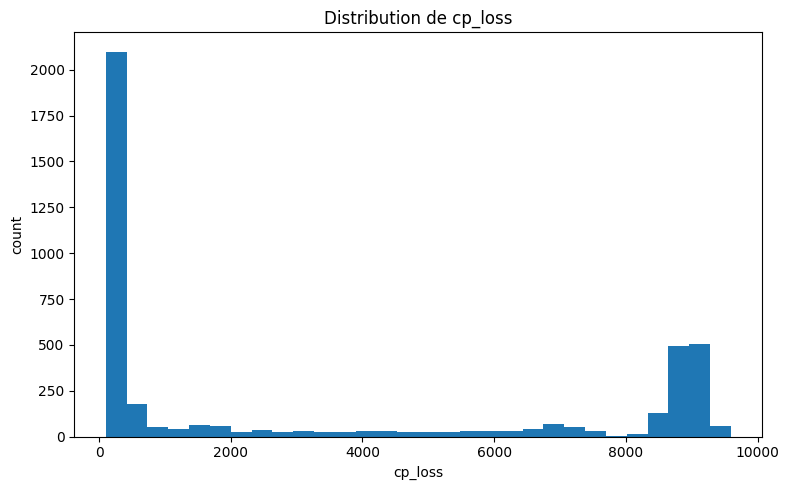

In [9]:
plot_hist(df["cp_loss"], PLOTS_DIR / "cp_loss_hist.png", "Distribution de cp_loss")

## Analyse par phase, cadence, résultat, Elo

In [10]:
phase_stats = pd.DataFrame()
if "phase" in df.columns:
    phase_stats = (
        df.groupby("phase", dropna=False)
        .agg(
            count=("cp_loss", "size"),
            mean_cp_loss=("cp_loss", "mean"),
            median_cp_loss=("cp_loss", "median"),
            hang_rate=("piece_hung_after_move", "mean") if "piece_hung_after_move" in df.columns else ("cp_loss", "size"),
            fork_rate=("opponent_has_fork_after", "mean") if "opponent_has_fork_after" in df.columns else ("cp_loss", "size"),
        )
        .reset_index()
        .sort_values(["mean_cp_loss", "count"], ascending=[False, False])
    )
    for col in ["mean_cp_loss", "median_cp_loss", "hang_rate", "fork_rate"]:
        if col in phase_stats.columns:
            phase_stats[col] = phase_stats[col].round(4)

phase_stats

,phase,count,mean_cp_loss,median_cp_loss,hang_rate,fork_rate
1,middlegame,1825,3609.6219,300.0,0.4630,0.2964
0,endgame,2396,3304.3093,845.0,0.2425,0.0142
2,opening,60,499.6167,158.0,0.4667,0.3167


In [11]:
speed_stats = pd.DataFrame()
if "speed" in df.columns:
    speed_stats = (
        df.groupby("speed", dropna=False)
        .agg(
            count=("cp_loss", "size"),
            mean_cp_loss=("cp_loss", "mean"),
            median_cp_loss=("cp_loss", "median"),
        )
        .reset_index()
        .sort_values(["mean_cp_loss", "count"], ascending=[False, False])
    )
    for col in ["mean_cp_loss", "median_cp_loss"]:
        if col in speed_stats.columns:
            speed_stats[col] = speed_stats[col].round(4)

speed_stats

,speed,count,mean_cp_loss,median_cp_loss
1,bullet,2370,3647.7734,399.5
2,classical,50,3226.5000,488.5
0,blitz,1395,3146.1477,520.0
3,rapid,466,2873.9013,491.0


In [12]:
result_stats = pd.DataFrame()
if "target_result" in df.columns:
    result_stats = (
        df.groupby("target_result", dropna=False)
        .agg(
            count=("cp_loss", "size"),
            mean_cp_loss=("cp_loss", "mean"),
            hang_rate=("piece_hung_after_move", "mean") if "piece_hung_after_move" in df.columns else ("cp_loss", "size"),
            fork_rate=("opponent_has_fork_after", "mean") if "opponent_has_fork_after" in df.columns else ("cp_loss", "size"),
        )
        .reset_index()
        .sort_values(["mean_cp_loss", "count"], ascending=[False, False])
    )
    for col in ["mean_cp_loss", "hang_rate", "fork_rate"]:
        if col in result_stats.columns:
            result_stats[col] = result_stats[col].round(4)

result_stats

,target_result,count,mean_cp_loss,hang_rate,fork_rate
0,draw,360,3455.6361,0.1972,0.0278
1,loss,2125,3397.0118,0.3845,0.1609
2,win,1796,3380.8369,0.3151,0.1347


In [13]:
elo_bucket_stats = pd.DataFrame()
if "target_elo_bucket" in df.columns:
    elo_bucket_stats = (
        df.groupby("target_elo_bucket", dropna=False)
        .agg(
            count=("cp_loss", "size"),
            mean_cp_loss=("cp_loss", "mean"),
            mean_king_danger_delta=("king_danger_delta", "mean") if "king_danger_delta" in df.columns else ("cp_loss", "size"),
            hang_rate=("piece_hung_after_move", "mean") if "piece_hung_after_move" in df.columns else ("cp_loss", "size"),
            fork_rate=("opponent_has_fork_after", "mean") if "opponent_has_fork_after" in df.columns else ("cp_loss", "size"),
        )
        .reset_index()
        .sort_values("target_elo_bucket")
    )
    for col in ["mean_cp_loss", "mean_king_danger_delta", "hang_rate", "fork_rate"]:
        if col in elo_bucket_stats.columns:
            elo_bucket_stats[col] = elo_bucket_stats[col].round(4)

elo_bucket_stats

,target_elo_bucket,count,mean_cp_loss,mean_king_danger_delta,hang_rate,fork_rate
0,"[0, 1200)",243,3306.8107,-0.2210,0.3663,0.1440
1,"[1200, 1400)",462,3201.3203,-0.3529,0.3333,0.1364
2,"[1400, 1600)",672,3272.5283,-0.3086,0.3170,0.1295
3,"[1600, 1800)",802,3445.9339,-0.3326,0.3741,0.1347
4,"[1800, 2000)",1034,3521.1673,-0.3051,0.3453,0.1460
5,"[2000, 2200)",914,3459.1149,-0.2484,0.3162,0.1433
6,"[2200, 3000)",154,3161.0455,-0.2695,0.3377,0.1234


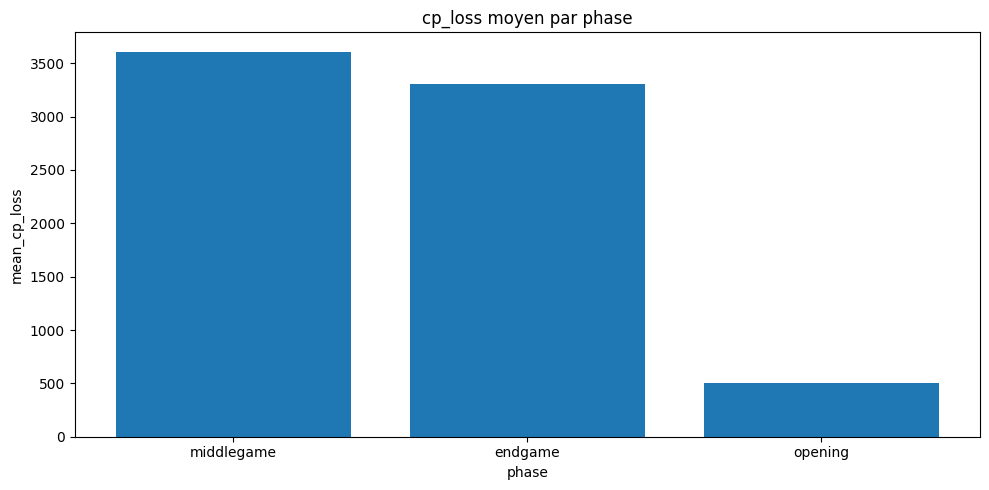

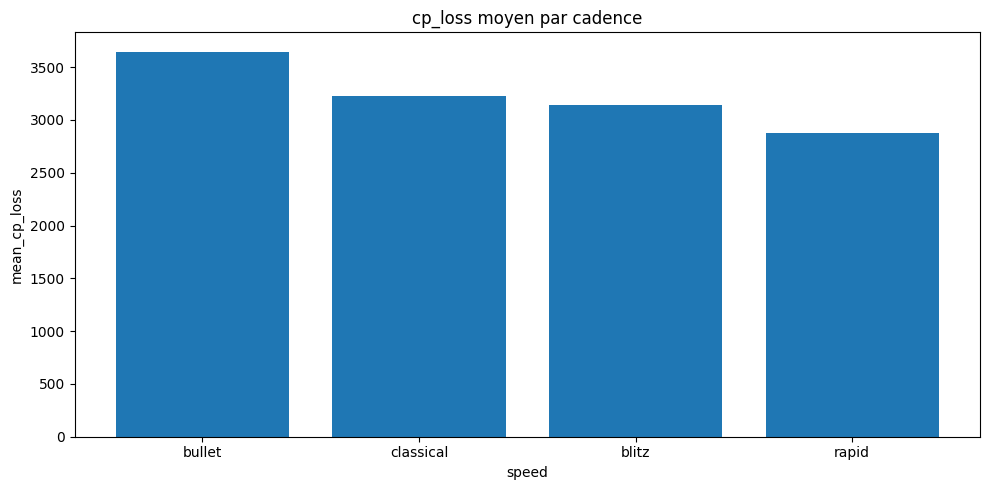

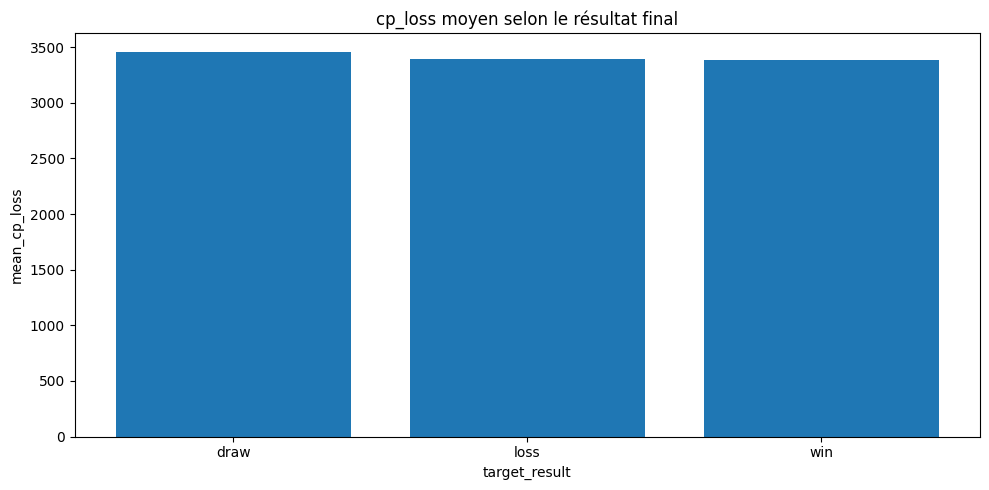

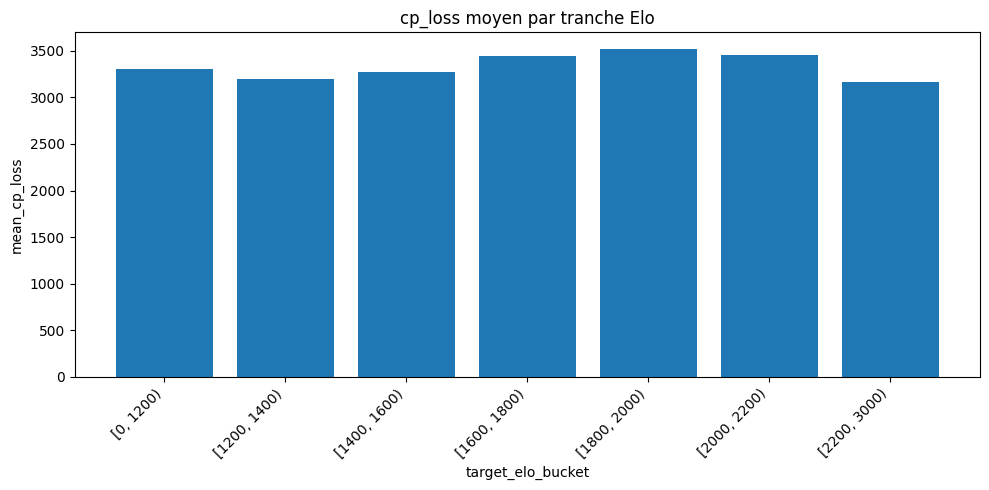

In [14]:
if not phase_stats.empty:
    plot_bar(phase_stats, "phase", "mean_cp_loss", PLOTS_DIR / "phase_mean_cp_loss.png", "cp_loss moyen par phase")

if not speed_stats.empty:
    plot_bar(speed_stats, "speed", "mean_cp_loss", PLOTS_DIR / "speed_mean_cp_loss.png", "cp_loss moyen par cadence")

if not result_stats.empty:
    plot_bar(result_stats, "target_result", "mean_cp_loss", PLOTS_DIR / "target_result_mean_cp_loss.png", "cp_loss moyen selon le résultat final")

if not elo_bucket_stats.empty:
    plot_bar(elo_bucket_stats, "target_elo_bucket", "mean_cp_loss", PLOTS_DIR / "elo_bucket_mean_cp_loss.png", "cp_loss moyen par tranche Elo", rotate=True)

## Ouvertures, transitions d'évaluation et exemples extrêmes

In [15]:
opening_name_stats = top_categories(df, "opening_name", TOP_N)
transition_stats = top_categories(df, "eval_state_transition", TOP_N)
opening_name_stats, transition_stats.head(10)

(                                    opening_name  count   share
 0                              Queen's Pawn Game    113  0.0264
 1                           Van't Kruijs Opening    109  0.0255
 2                              Caro-Kann Defense     86  0.0201
 3                                Horwitz Defense     73  0.0171
 4                                   Pirc Defense     67  0.0157
 5             French Defense: Exchange Variation     65  0.0152
 6   Queen's Pawn Game: Accelerated London System     64  0.0149
 7                                 Modern Defense     63  0.0147
 8                           Scandinavian Defense     59  0.0138
 9                              Hungarian Opening     54  0.0126
 10                                Mieses Opening     50  0.0117
 11                              Philidor Defense     50  0.0117
 12             Queen's Pawn Game: Modern Defense     50  0.0117
 13              French Defense: Knight Variation     43  0.0100
 14                      

In [16]:
worst_examples = examples_table(df, 25)
worst_examples.head(15)

,phase,speed,opening_name,target_elo,opponent_elo,move_san,cp_loss,move_quality,eval_state_transition,piece_hung_after_move,hung_piece_type,king_danger_delta,checks_available_to_opponent_after,opponent_has_fork_after,opponent_has_discovered_attack_after,opponent_can_trap_piece_after_move,opponent_has_smothered_mate_pattern_after
0,endgame,blitz,Sicilian Defense: Taimanov Variation,1631,1906,Kd5,9595.0,Blunder,losing_to_losing,False,,0.90,2,False,False,False,False
1,endgame,blitz,Queen's Gambit Declined: Harrwitz Attack,2176,2168,Kf4,9575.0,Blunder,losing_to_losing,False,,0.90,2,False,False,False,False
2,endgame,blitz,Queen's Gambit Declined: Harrwitz Attack,2176,2168,Kf5,9539.0,Blunder,losing_to_losing,False,,-0.90,2,False,False,False,False
3,middlegame,blitz,Queen's Pawn Game: Accelerated London System,2123,2165,Rdd7,9522.0,Blunder,losing_to_losing,False,,0.00,1,True,True,False,False
4,middlegame,bullet,Alekhine Defense: Maróczy Variation,1365,1772,Kf3+,9518.0,Blunder,losing_to_losing,False,,-1.65,1,False,False,False,False
5,endgame,bullet,"Alekhine Defense: Scandinavian Variation, Gesc...",1872,2429,Rxf7,9514.0,Blunder,losing_to_losing,False,,0.00,3,False,False,False,True
6,middlegame,rapid,Queen's Pawn Game: Chigorin Variation,1445,1489,Kd4,9513.0,Blunder,losing_to_losing,False,,0.80,10,False,False,False,False
7,middlegame,blitz,Queen's Pawn Game: Accelerated London System,1254,1348,Qh5,9493.0,Blunder,winning_to_winning,False,,0.00,1,True,True,False,False
8,endgame,bullet,French Defense: Knight Variation,1810,2043,Kb6,9485.0,Blunder,losing_to_losing,False,,1.20,0,False,False,False,False
9,endgame,blitz,French Defense: Knight Variation,1291,1273,Kg7,9481.0,Blunder,winning_to_winning,False,,0.45,0,False,False,False,False


## Pièces pendues et mécanismes matériels

In [17]:
hung_piece_stats = top_hung_pieces(df, TOP_N)
hung_piece_stats

,hung_piece_type,count,share_within_hangs,mean_cp_loss
0,Pawn,887,0.6100,3257.322
1,Rook,233,0.1602,3667.382
2,Bishop,121,0.0832,3136.959
3,Knight,115,0.0791,2400.852
4,Queen,98,0.0674,3149.163


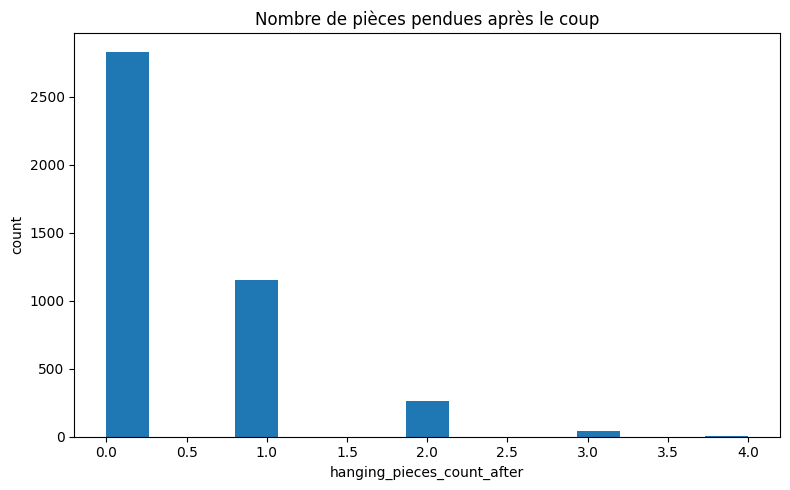

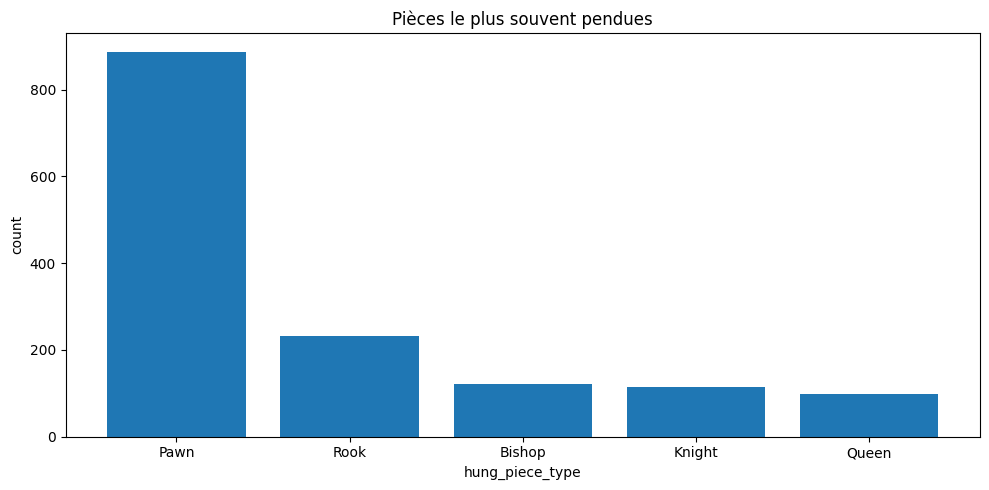

In [18]:
if "hanging_pieces_count_after" in df.columns:
    plot_hist(
        df["hanging_pieces_count_after"],
        PLOTS_DIR / "hanging_pieces_count_hist.png",
        "Nombre de pièces pendues après le coup",
        bins=15,
    )

if not hung_piece_stats.empty:
    plot_bar(
        hung_piece_stats,
        "hung_piece_type",
        "count",
        PLOTS_DIR / "hung_piece_type_counts.png",
        "Pièces le plus souvent pendues",
    )

## Signaux de sécurité du roi

In [19]:
king_table = describe_numeric(df, ["king_danger_before", "king_danger_after", "king_danger_delta", "king_escape_squares_after", "checks_available_to_opponent_after"])
king_table

,feature,count,mean,median,std,min,p10,p90,max
0,king_danger_before,4281,2.999,2.85,2.230,-0.6,0.0,5.85,11.20
1,king_danger_after,4281,2.702,2.55,1.930,-0.6,0.0,5.35,9.45
2,king_danger_delta,4281,-0.298,0.00,1.151,-8.1,-1.8,0.45,4.25
3,king_escape_squares_after,4281,3.878,4.00,1.986,0.0,1.0,7.00,8.00
4,checks_available_to_opponent_after,4281,1.061,0.00,1.852,0.0,0.0,3.00,12.00


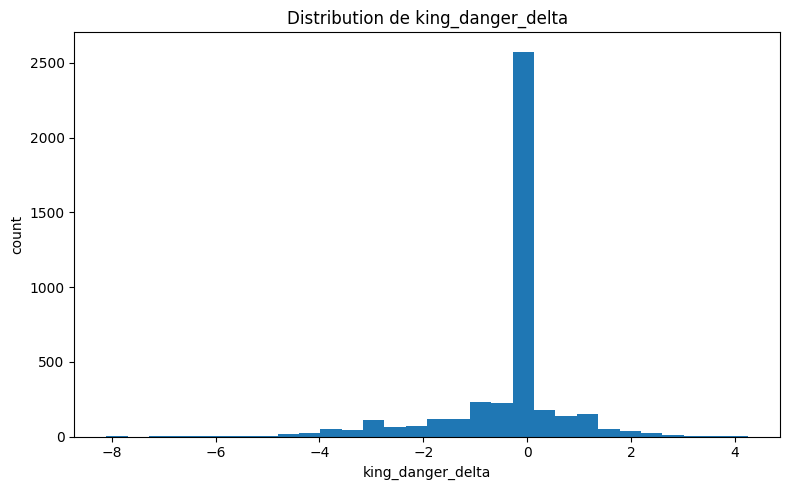

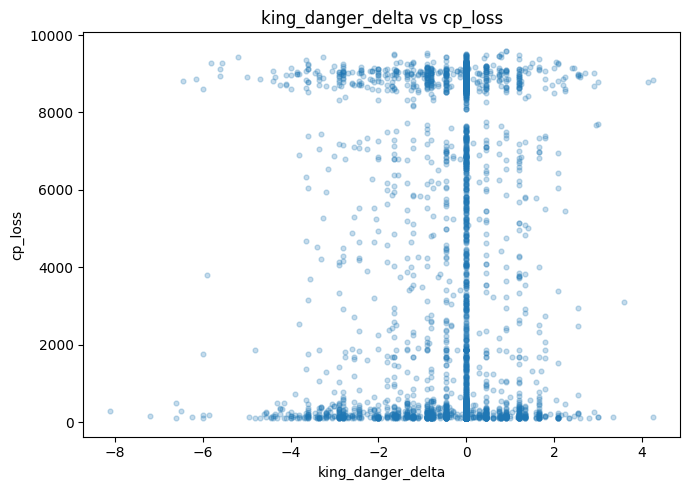

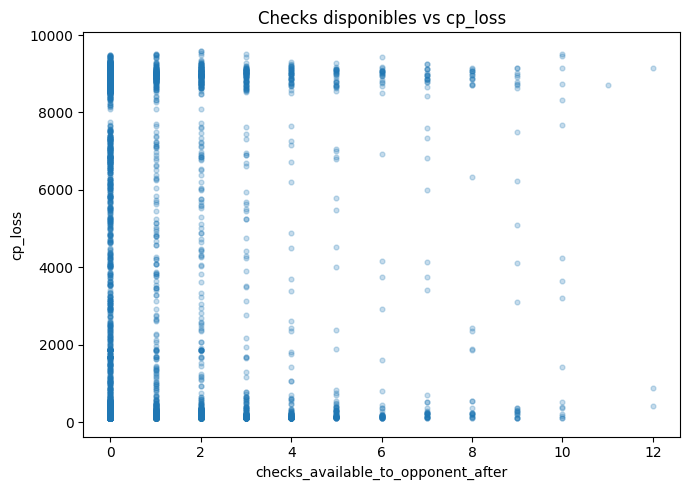

In [20]:
if "king_danger_delta" in df.columns:
    plot_hist(df["king_danger_delta"], PLOTS_DIR / "king_danger_delta_hist.png", "Distribution de king_danger_delta")

if "king_danger_delta" in df.columns and "cp_loss" in df.columns:
    plot_scatter(df, "king_danger_delta", "cp_loss", PLOTS_DIR / "king_danger_vs_cp_loss.png", "king_danger_delta vs cp_loss")

if "checks_available_to_opponent_after" in df.columns and "cp_loss" in df.columns:
    plot_scatter(df, "checks_available_to_opponent_after", "cp_loss", PLOTS_DIR / "checks_available_vs_cp_loss.png", "Checks disponibles vs cp_loss")

## Motifs tactiques booléens

In [21]:
flag_summary = summarize_boolean_flags(df, TACTICAL_FLAGS)
flag_summary

,feature,count_true,rate_true
0,opponent_has_discovered_attack_after,1890,0.4415
1,opponent_has_double_attack_after,1608,0.3756
2,piece_hung_after_move,1454,0.3396
3,back_rank_weak_after,835,0.1950
4,opponent_has_fork_after,594,0.1388
5,opponent_can_trap_piece_after_move,426,0.0995
6,opponent_has_knight_fork_after,69,0.0161
7,opponent_has_smothered_mate_pattern_after,20,0.0047
8,opponent_has_pawn_fork_after,13,0.0030
9,lost_castling_rights,11,0.0026


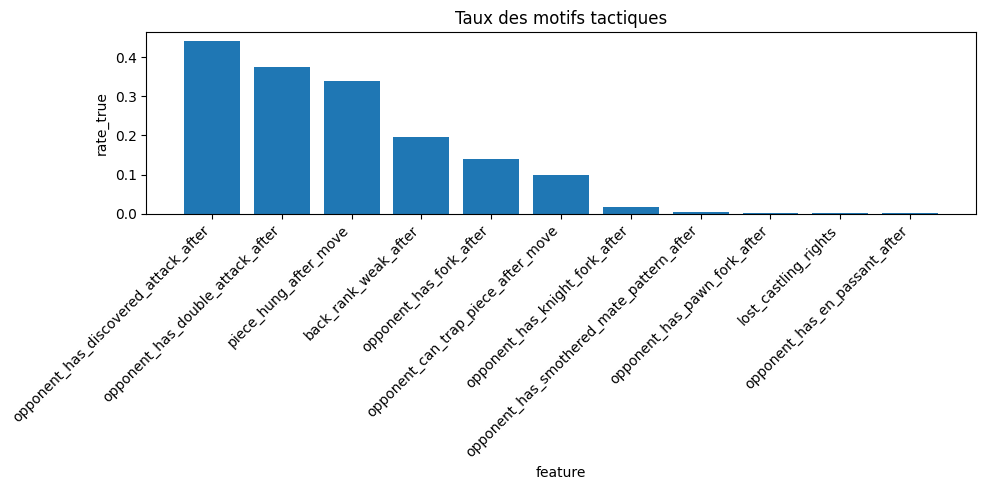

In [22]:
plot_bar(flag_summary, "feature", "rate_true", PLOTS_DIR / "tactical_flag_rates.png", "Taux des motifs tactiques", rotate=True)

In [23]:
flag_tables = {}
for flag in TACTICAL_FLAGS:
    if flag in df.columns:
        flag_tables[f"{flag}_by_move_quality"] = bool_rate_by_group(df, "move_quality", flag)
        flag_tables[f"{flag}_by_phase"] = bool_rate_by_group(df, "phase", flag)
        flag_tables[f"{flag}_by_elo_bucket"] = bool_rate_by_group(df, "target_elo_bucket", flag)

next(iter(flag_tables.items())) if flag_tables else "Aucun flag exploitable" 

('piece_hung_after_move_by_move_quality',
   move_quality  count    rate
 1      Mistake   1467  0.4042
 0      Blunder   2814  0.3060)

## Corrélations et pires sous-groupes

In [24]:
correlations = correlation_table(df)
correlations

,feature,corr_with_cp_loss
0,eval_player_before_cp,0.4914
1,eval_player_after_cp,-0.3921
2,checks_available_to_opponent_after,0.0320
3,material_balance_after_move_cp,0.0230
4,material_balance_before_cp,0.0221
5,hanging_pieces_count_after,-0.0211
6,king_escape_squares_after,0.0201
7,opponent_elo,0.0187
8,target_elo,0.0146
9,king_danger_before,-0.0089


In [25]:
worst_slices = slice_ranking(df, ["phase", "speed", "opening_name"], MIN_GROUP_SIZE)
worst_slices.head(20)

,phase,speed,opening_name,count,mean_cp_loss,median_cp_loss,mean_king_danger_delta,piece_hung_rate,fork_rate
0,middlegame,bullet,Van't Kruijs Opening,44,4653.1136,6588.0,-0.2727,0.3864,0.2273
1,endgame,bullet,Horwitz Defense,26,4500.7692,4439.0,-0.1077,0.1538,0.0000
2,middlegame,bullet,Hungarian Opening,27,3757.2222,365.0,-0.1056,0.5185,0.2593
3,endgame,blitz,Caro-Kann Defense,25,3696.9200,2767.0,-0.0120,0.3200,0.0000
4,middlegame,bullet,Horwitz Defense,28,3613.8214,160.0,-0.5107,0.3214,0.2857
5,endgame,bullet,Van't Kruijs Opening,39,3470.7949,367.0,-0.2718,0.3077,0.0513
6,endgame,bullet,Queen's Pawn Game,42,3231.6190,745.0,-0.3857,0.2857,0.0714
7,middlegame,bullet,Queen's Pawn Game,40,3005.1000,250.5,-0.0875,0.4750,0.2500


## Comparaison `Mistake` / `Blunder`

In [26]:
quality_stats = group_quality_stats(df)
quality_stats

,move_quality,count,cp_loss_mean,cp_loss_median,king_danger_delta_mean,king_danger_delta_median,checks_available_to_opponent_after_mean,checks_available_to_opponent_after_median,hanging_pieces_count_after_mean,hanging_pieces_count_after_median,...,lost_castling_rights_rate,back_rank_weak_after_rate,opponent_has_en_passant_after_rate,opponent_has_double_attack_after_rate,opponent_has_fork_after_rate,opponent_has_knight_fork_after_rate,opponent_has_pawn_fork_after_rate,opponent_has_discovered_attack_after_rate,opponent_can_trap_piece_after_move_rate,opponent_has_smothered_mate_pattern_after_rate
0,Blunder,2814,5094.951,6288.0,-0.309,0.0,1.100,0.0,0.374,0.0,...,0.0011,0.1485,0.0007,0.3213,0.0928,0.0100,0.0028,0.3845,0.0842,0.0028
1,Mistake,1467,134.607,128.0,-0.276,0.0,0.988,0.0,0.513,0.0,...,0.0055,0.2843,0.0020,0.4799,0.2270,0.0279,0.0034,0.5508,0.1288,0.0082


/tmp/ipykernel_39116/4089553653.py:268: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


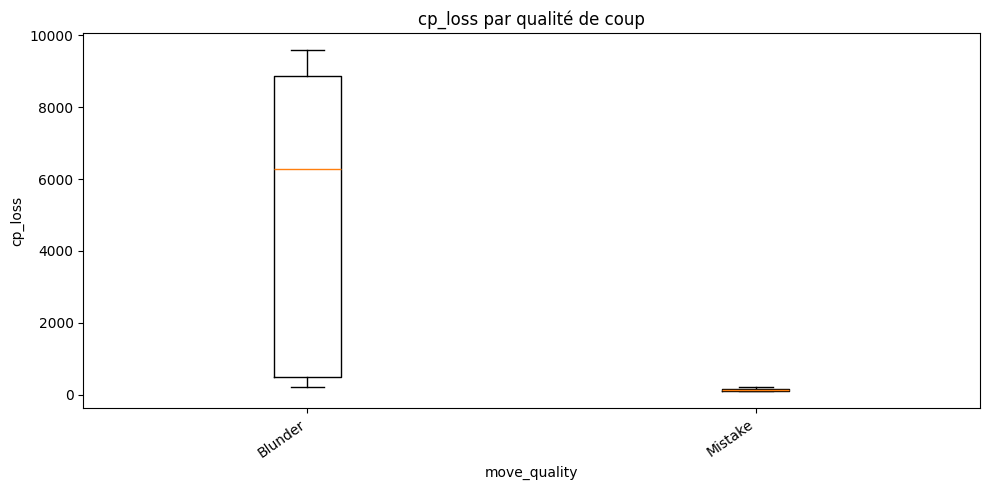

In [27]:
plot_box_by_group(df, "cp_loss", "move_quality", PLOTS_DIR / "cp_loss_by_move_quality_box.png", "cp_loss par qualité de coup")

## Sauvegarde de tous les tableaux

In [28]:
tables = {
    "numeric_summary": numeric_summary,
    "missingness": missingness,
    "flag_summary": flag_summary,
    "quality_stats": quality_stats,
    "phase_stats": phase_stats,
    "speed_stats": speed_stats,
    "result_stats": result_stats,
    "elo_bucket_stats": elo_bucket_stats,
    "transition_stats": transition_stats,
    "opening_name_stats": opening_name_stats,
    "top_hung_pieces": hung_piece_stats,
    "correlations": correlations,
    "worst_slices": worst_slices,
    "worst_examples": worst_examples,
    "king_table": king_table,
}
for name, table in tables.items():
    if isinstance(table, (pd.DataFrame, pd.Series)) and not table.empty:
        save_table(table, TABLES_DIR / f"{name}.csv")

for name, table in flag_tables.items():
    if isinstance(table, pd.DataFrame) and not table.empty:
        save_table(table, TABLES_DIR / f"{name}.csv")

sorted(p.name for p in TABLES_DIR.glob("*.csv"))[:20]

['back_rank_weak_after_by_elo_bucket.csv',
 'back_rank_weak_after_by_move_quality.csv',
 'back_rank_weak_after_by_phase.csv',
 'correlations.csv',
 'elo_bucket_stats.csv',
 'flag_summary.csv',
 'king_table.csv',
 'lost_castling_rights_by_elo_bucket.csv',
 'lost_castling_rights_by_move_quality.csv',
 'lost_castling_rights_by_phase.csv',
 'missingness.csv',
 'numeric_summary.csv',
 'opening_name_stats.csv',
 'opponent_can_trap_piece_after_move_by_elo_bucket.csv',
 'opponent_can_trap_piece_after_move_by_move_quality.csv',
 'opponent_can_trap_piece_after_move_by_phase.csv',
 'opponent_has_discovered_attack_after_by_elo_bucket.csv',
 'opponent_has_discovered_attack_after_by_move_quality.csv',
 'opponent_has_discovered_attack_after_by_phase.csv',
 'opponent_has_double_attack_after_by_elo_bucket.csv']